# Family-fix all-alpha final double check

This notebook performs the **all-alpha final deployed double check** using the saved
`deploy_full_by_alpha_rep*.npz` files from the family-fix runs.

Project rule for this notebook:

- The target is **pointwise deployed coverage near 0.95**
- We care about whether the dictionary and the selected `alpha*(x)` actually calibrate each test point in the **final deployed double check**
- Until the project focus changes, **overcoverage is not treated as the main issue**
- The main focus is the set of points where the selected deployed double check remains **undercovered**

This notebook does the following:

1. Loads all replications from the local `results` folder
2. Builds the **estimated** all-alpha coverage tensor from `pointwise_coverage_rep*.csv`
3. Builds the **actual final-deployed** all-alpha coverage tensor from `deploy_full_by_alpha_rep*.npz`
4. Focuses on the points where the selected deployed double check is under nominal
5. Saves tables and plots for:
   - selected undercovered points
   - all-alpha estimated coverage on those points
   - all-alpha actual deployed coverage on those points
   - all-alpha actual-minus-estimated gap on those points
   - best-alpha-by-estimate vs best-alpha-by-actual summaries


In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 160

# Adjust if needed
RESULTS_DIR = Path(r"C:\Users\yangy\26 spring\with reference\familyfix\results")
OUTPUT_DIR = RESULTS_DIR / "all_alpha_final_double_check"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR, OUTPUT_DIR

(WindowsPath('C:/Users/yangy/26 spring/with reference/familyfix/results'),
 WindowsPath('C:/Users/yangy/26 spring/with reference/familyfix/results/all_alpha_final_double_check'))

In [2]:
DEPLOY_SELECTED_PATTERN = "deploy_final_rep*_J*.csv"
DEPLOY_BANK_PATTERN = "deploy_full_by_alpha_rep*_A*_J*.npz"
COVERAGE_PATTERN = "pointwise_coverage_rep*_A*_B*.csv"
ALPHA_STAR_PATTERN = "alpha_star_curve_rep*.csv"
META_PATTERN = "meta_rep*.json"

rep_regex = re.compile(r"rep(\d+)")

def parse_rep_id(path: Path) -> int:
    m = rep_regex.search(path.stem)
    if m is None:
        raise ValueError(f"Could not parse rep id from {path.name}")
    return int(m.group(1))

def load_optional_json(path: Path):
    if path is None or not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

deploy_selected_files = sorted(RESULTS_DIR.glob(DEPLOY_SELECTED_PATTERN), key=parse_rep_id)
deploy_bank_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(DEPLOY_BANK_PATTERN)}
coverage_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(COVERAGE_PATTERN)}
alpha_star_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(ALPHA_STAR_PATTERN)}
meta_files = {parse_rep_id(p): p for p in RESULTS_DIR.glob(META_PATTERN)}

print(f"Found {len(deploy_selected_files)} selected deploy files")
print(f"Found {len(deploy_bank_files)} deploy alpha-bank files")
print(f"Found {len(coverage_files)} pointwise coverage files")
print(f"Found {len(alpha_star_files)} alpha-star files")
print(f"Found {len(meta_files)} meta files")

if len(deploy_selected_files) == 0:
    raise FileNotFoundError(f"No files matching {DEPLOY_SELECTED_PATTERN} were found in {RESULTS_DIR}")

missing_bank = [parse_rep_id(p) for p in deploy_selected_files if parse_rep_id(p) not in deploy_bank_files]
if missing_bank:
    raise FileNotFoundError(
        "Some replications are missing deploy_full_by_alpha files. "
        f"Missing rep ids: {missing_bank[:10]}"
    )

Found 100 selected deploy files
Found 100 deploy alpha-bank files
Found 100 pointwise coverage files
Found 100 alpha-star files
Found 100 meta files


In [3]:
records = []
x_ref = None
true_f_ref = None
ci_level = None
alpha_vals_ref = None

for deploy_path in deploy_selected_files:
    rep_id = parse_rep_id(deploy_path)
    deploy_df = pd.read_csv(deploy_path).sort_values("x").reset_index(drop=True)

    if x_ref is None:
        x_ref = deploy_df["x"].to_numpy(dtype=float)
        true_f_ref = deploy_df["true_f"].to_numpy(dtype=float)
    else:
        if not np.allclose(x_ref, deploy_df["x"].to_numpy(dtype=float)):
            raise ValueError(f"x-grid mismatch in selected deploy file for rep {rep_id}")
        if not np.allclose(true_f_ref, deploy_df["true_f"].to_numpy(dtype=float)):
            raise ValueError(f"true_f mismatch in selected deploy file for rep {rep_id}")

    meta = load_optional_json(meta_files.get(rep_id))
    if meta is not None and ci_level is None:
        ci_level = float(meta.get("ci_level", np.nan))

    # estimated split-bootstrap coverage for all alphas
    cov_path = coverage_files.get(rep_id)
    if cov_path is None:
        raise FileNotFoundError(f"Missing coverage CSV for rep {rep_id}")
    cov_df = pd.read_csv(cov_path).sort_values("x").reset_index(drop=True)
    if not np.allclose(x_ref, cov_df["x"].to_numpy(dtype=float)):
        raise ValueError(f"x-grid mismatch in pointwise coverage file for rep {rep_id}")
    alpha_cols = [c for c in cov_df.columns if c.startswith("alpha_")]
    alpha_vals = np.array([float(c.split("_", 1)[1]) for c in alpha_cols], dtype=float)
    order = np.argsort(alpha_vals)
    alpha_cols = [alpha_cols[i] for i in order]
    alpha_vals = alpha_vals[order]
    cov_df = cov_df[["x"] + alpha_cols].copy()

    # actual final-deployed alpha bank
    bank_path = deploy_bank_files.get(rep_id)
    bank = np.load(bank_path)
    bank_x = np.array(bank["x"], dtype=float)
    bank_alphas = np.array(bank["alphas"], dtype=float)
    mu_bank = np.array(bank["mu"], dtype=float)
    std_bank = np.array(bank["std"], dtype=float)
    lower_bank = np.array(bank["lower"], dtype=float)
    upper_bank = np.array(bank["upper"], dtype=float)

    if not np.allclose(x_ref, bank_x):
        raise ValueError(f"x-grid mismatch in deploy alpha bank for rep {rep_id}")
    if alpha_vals_ref is None:
        alpha_vals_ref = bank_alphas.copy()
    else:
        if len(alpha_vals_ref) != len(bank_alphas) or not np.allclose(alpha_vals_ref, bank_alphas):
            raise ValueError(f"alpha grid mismatch in deploy alpha bank for rep {rep_id}")

    if len(alpha_vals) != len(bank_alphas) or not np.allclose(alpha_vals, bank_alphas):
        raise ValueError(f"coverage-vs-bank alpha grid mismatch for rep {rep_id}")

    # alpha-star curve
    alpha_df = None
    alpha_path = alpha_star_files.get(rep_id)
    if alpha_path is not None:
        alpha_df = pd.read_csv(alpha_path).sort_values("x").reset_index(drop=True)
        if not np.allclose(x_ref, alpha_df["x"].to_numpy(dtype=float)):
            raise ValueError(f"x-grid mismatch in alpha_star file for rep {rep_id}")

    records.append({
        "rep_id": rep_id,
        "deploy_df": deploy_df,
        "coverage_df": cov_df,
        "alpha_vals": alpha_vals,
        "alpha_df": alpha_df,
        "meta": meta,
        "mu_bank": mu_bank,
        "std_bank": std_bank,
        "lower_bank": lower_bank,
        "upper_bank": upper_bank,
    })

print(f"Loaded {len(records)} replications")
print(f"Nominal CI level from meta: {ci_level}")
print(f"Alpha grid: {alpha_vals_ref}")

Loaded 100 replications
Nominal CI level from meta: 0.95
Alpha grid: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [4]:
rep_ids = np.array([r["rep_id"] for r in records], dtype=int)
R = len(records)
J = len(x_ref)
A = len(alpha_vals_ref)
nominal = float(ci_level) if ci_level is not None else 0.95

# selected deployed double-check
selected_hit_mat = np.vstack([r["deploy_df"]["hit"].to_numpy(dtype=float) for r in records])
selected_alpha_star_mat = np.vstack([r["deploy_df"]["alpha_star"].to_numpy(dtype=float) for r in records])

# estimated all-alpha coverage tensor: shape (R, J, A)
est_cov_all_tensor = np.stack(
    [r["coverage_df"].iloc[:, 1:].to_numpy(dtype=float) for r in records],
    axis=0,
)

# actual all-alpha final-deployed hit tensor and actual coverage tensor
actual_hit_all_tensor = np.zeros((R, J, A), dtype=float)
for r_idx, rec in enumerate(records):
    lower_bank = rec["lower_bank"]   # shape (A, J)
    upper_bank = rec["upper_bank"]   # shape (A, J)
    true_f = rec["deploy_df"]["true_f"].to_numpy(dtype=float)  # shape (J,)
    hit_bank = ((true_f[None, :] >= lower_bank) & (true_f[None, :] <= upper_bank)).astype(float)  # (A, J)
    actual_hit_all_tensor[r_idx] = hit_bank.T  # -> (J, A)

# means across replications
pointwise_selected_deploy_cov = selected_hit_mat.mean(axis=0)
pointwise_selected_est_cov = np.vstack([
    rec["coverage_df"].iloc[np.arange(J), 1 + np.array([
        int(np.argmin(np.abs(alpha_vals_ref - float(a)))) for a in rec["deploy_df"]["alpha_star"].to_numpy(dtype=float)
    ])].to_numpy(dtype=float)
    for rec in records
]).mean(axis=0)

actual_cov_all_mean = actual_hit_all_tensor.mean(axis=0)    # shape (J, A)
actual_cov_all_sd = actual_hit_all_tensor.std(axis=0, ddof=1) if R > 1 else np.zeros((J, A))
est_cov_all_mean = est_cov_all_tensor.mean(axis=0)          # shape (J, A)
est_cov_all_sd = est_cov_all_tensor.std(axis=0, ddof=1) if R > 1 else np.zeros((J, A))
gap_actual_minus_est_mean = actual_cov_all_mean - est_cov_all_mean

summary = {
    "R": int(R),
    "J": int(J),
    "A": int(A),
    "rep_id_min": int(rep_ids.min()),
    "rep_id_max": int(rep_ids.max()),
    "nominal": float(nominal),
    "undercovered_selected_points": int(np.sum(pointwise_selected_deploy_cov < nominal)),
}
summary

{'R': 100,
 'J': 50,
 'A': 10,
 'rep_id_min': 0,
 'rep_id_max': 99,
 'nominal': 0.95,
 'undercovered_selected_points': 9}

In [5]:
pointwise_selected_table = pd.DataFrame({
    "x": x_ref,
    "true_f": true_f_ref,
    "selected_deploy_coverage": pointwise_selected_deploy_cov,
    "selected_estimated_coverage": pointwise_selected_est_cov,
    "selected_deploy_minus_estimated": pointwise_selected_deploy_cov - pointwise_selected_est_cov,
    "alpha_star_mean": selected_alpha_star_mat.mean(axis=0),
    "alpha_star_sd": selected_alpha_star_mat.std(axis=0, ddof=1) if R > 1 else np.zeros(J),
    "nominal": nominal,
    "selected_gap_to_nominal": nominal - pointwise_selected_deploy_cov,
})
pointwise_selected_table.to_csv(OUTPUT_DIR / "00_pointwise_selected_summary.csv", index=False)

under_mask = pointwise_selected_deploy_cov < nominal
under_idx = np.flatnonzero(under_mask)
U = len(under_idx)

print(f"Undercovered points under selected deployed double check: {U} / {J}")

undercovered_selected_summary = pointwise_selected_table.loc[under_mask].copy()
undercovered_selected_summary = undercovered_selected_summary.sort_values(
    ["selected_gap_to_nominal", "x"], ascending=[False, True]
).reset_index(drop=True)
undercovered_selected_summary.to_csv(
    OUTPUT_DIR / "01_undercovered_selected_points_summary.csv",
    index=False,
)
undercovered_selected_summary

Undercovered points under selected deployed double check: 9 / 50


,x,true_f,selected_deploy_coverage,selected_estimated_coverage,selected_deploy_minus_estimated,alpha_star_mean,alpha_star_sd,nominal,selected_gap_to_nominal
0,-1.887755,1.055191,0.84,0.984078,-0.144078,0.755,0.249596,0.95,0.11
1,-1.581633,0.506969,0.84,0.972408,-0.132408,0.961,0.116250,0.95,0.11
2,-2.193878,-0.460571,0.87,0.984630,-0.114630,0.698,0.291281,0.95,0.08
3,-2.295918,-0.547295,0.88,0.978084,-0.098084,0.832,0.253811,0.95,0.07
4,-1.989796,0.539654,0.89,0.970270,-0.080270,0.987,0.067652,0.95,0.06
5,-1.479592,-0.262983,0.91,0.981404,-0.071404,0.782,0.243036,0.95,0.04
6,-1.173469,-1.351151,0.92,0.972572,-0.052572,0.976,0.099615,0.95,0.03
7,2.091837,1.045520,0.94,0.985154,-0.045154,0.746,0.275395,0.95,0.01
8,2.500000,0.173318,0.94,0.977228,-0.037228,0.897,0.217634,0.95,0.01


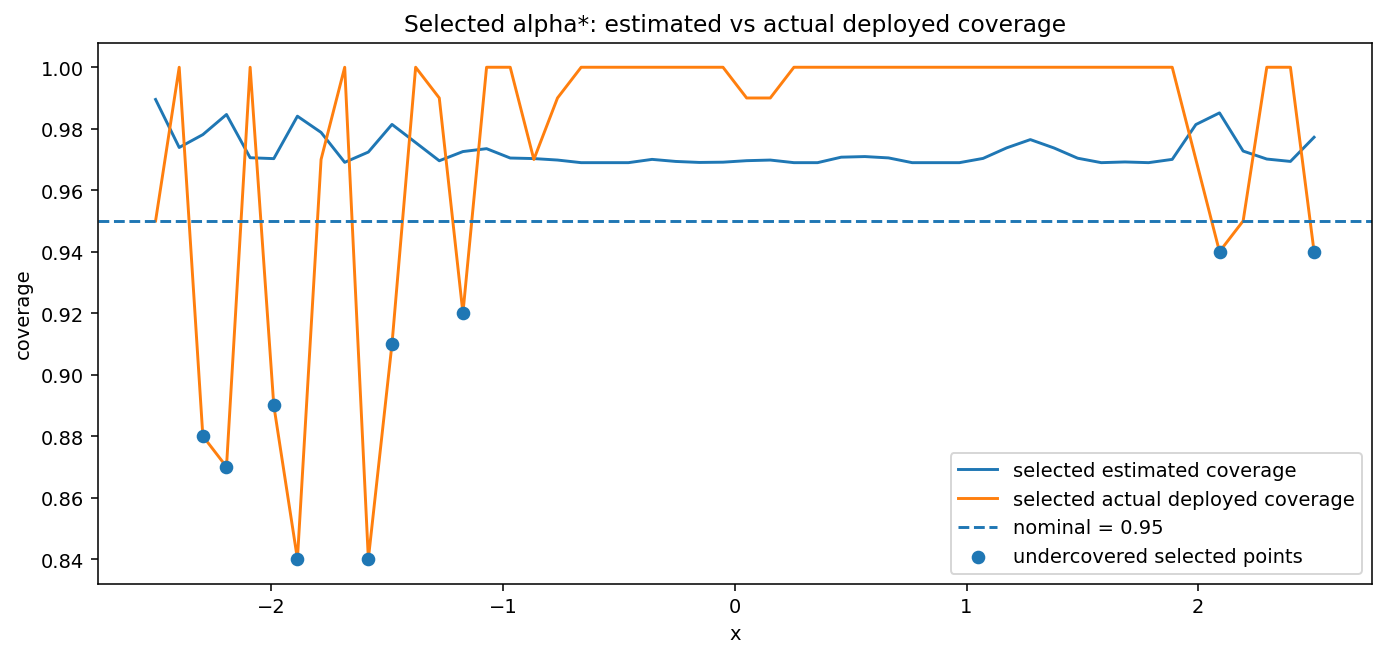

In [6]:
# Diagnostic plot: selected estimated vs selected actual, highlighting undercovered points
plt.figure(figsize=(10, 4.8))
plt.plot(x_ref, pointwise_selected_est_cov, label="selected estimated coverage")
plt.plot(x_ref, pointwise_selected_deploy_cov, label="selected actual deployed coverage")
plt.axhline(nominal, linestyle="--", label=f"nominal = {nominal:.2f}")
if U > 0:
    plt.scatter(
        x_ref[under_idx],
        pointwise_selected_deploy_cov[under_idx],
        label="undercovered selected points",
        zorder=3,
    )
plt.xlabel("x")
plt.ylabel("coverage")
plt.title("Selected alpha*: estimated vs actual deployed coverage")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_selected_estimated_vs_actual.png", bbox_inches="tight")
plt.show()

## Diagnostic 1: all-alpha actual deployed coverage on the selected-undercovered points

For each point that remains undercovered under the selected `alpha*(x)`, inspect the
full deployed pointwise coverage for **every alpha in the dictionary**.

This answers:

- Is there an alpha in the dictionary whose **actual deployed** coverage is near 0.95?
- Or does the final deployed family itself fail to offer a good candidate on that point?
- How different is **actual deployed** all-alpha coverage from the **estimated** split-bootstrap coverage?


In [7]:
alpha_actual_mean_df = pd.DataFrame(
    actual_cov_all_mean,
    columns=[f"alpha_{a:.4f}_actual" for a in alpha_vals_ref],
)
alpha_actual_sd_df = pd.DataFrame(
    actual_cov_all_sd,
    columns=[f"alpha_{a:.4f}_actual_sd" for a in alpha_vals_ref],
)
alpha_est_mean_df = pd.DataFrame(
    est_cov_all_mean,
    columns=[f"alpha_{a:.4f}_estimated" for a in alpha_vals_ref],
)

all_alpha_compare = pd.concat(
    [
        pointwise_selected_table[[
            "x",
            "true_f",
            "selected_deploy_coverage",
            "selected_estimated_coverage",
            "selected_deploy_minus_estimated",
            "alpha_star_mean",
            "alpha_star_sd",
        ]].reset_index(drop=True),
        alpha_est_mean_df.reset_index(drop=True),
        alpha_actual_mean_df.reset_index(drop=True),
        alpha_actual_sd_df.reset_index(drop=True),
    ],
    axis=1,
)

undercovered_all_alpha_compare = all_alpha_compare.loc[under_mask].copy()

# best alpha by estimated mean
est_cols = [f"alpha_{a:.4f}_estimated" for a in alpha_vals_ref]
est_mat_under = undercovered_all_alpha_compare[est_cols].to_numpy(dtype=float)
best_est_idx = np.argmin(np.abs(est_mat_under - nominal), axis=1)
best_alpha_by_est = alpha_vals_ref[best_est_idx]
best_est_cov = est_mat_under[np.arange(U), best_est_idx]
best_est_abs_err = np.abs(best_est_cov - nominal)

# best alpha by actual deployed mean
act_cols = [f"alpha_{a:.4f}_actual" for a in alpha_vals_ref]
act_mat_under = undercovered_all_alpha_compare[act_cols].to_numpy(dtype=float)
best_act_idx = np.argmin(np.abs(act_mat_under - nominal), axis=1)
best_alpha_by_actual = alpha_vals_ref[best_act_idx]
best_actual_cov = act_mat_under[np.arange(U), best_act_idx]
best_actual_abs_err = np.abs(best_actual_cov - nominal)

undercovered_all_alpha_compare["best_alpha_by_estimated_mean"] = best_alpha_by_est
undercovered_all_alpha_compare["best_alpha_estimated_coverage"] = best_est_cov
undercovered_all_alpha_compare["best_alpha_estimated_abs_error_to_nominal"] = best_est_abs_err
undercovered_all_alpha_compare["best_alpha_by_actual_deploy_mean"] = best_alpha_by_actual
undercovered_all_alpha_compare["best_alpha_actual_deploy_coverage"] = best_actual_cov
undercovered_all_alpha_compare["best_alpha_actual_abs_error_to_nominal"] = best_actual_abs_err
undercovered_all_alpha_compare["best_actual_minus_best_est"] = (
    undercovered_all_alpha_compare["best_alpha_actual_deploy_coverage"]
    - undercovered_all_alpha_compare["best_alpha_estimated_coverage"]
)

undercovered_all_alpha_compare.to_csv(
    OUTPUT_DIR / "02_undercovered_all_alpha_actual_vs_estimated.csv",
    index=False,
)

undercovered_all_alpha_compare[[
    "x",
    "selected_deploy_coverage",
    "selected_estimated_coverage",
    "best_alpha_by_estimated_mean",
    "best_alpha_estimated_coverage",
    "best_alpha_by_actual_deploy_mean",
    "best_alpha_actual_deploy_coverage",
    "best_alpha_actual_abs_error_to_nominal",
]]

,x,selected_deploy_coverage,selected_estimated_coverage,best_alpha_by_estimated_mean,best_alpha_estimated_coverage,best_alpha_by_actual_deploy_mean,best_alpha_actual_deploy_coverage,best_alpha_actual_abs_error_to_nominal
2,-2.295918,0.88,0.978084,0.7,0.9505,0.5,0.95,0.00
3,-2.193878,0.87,0.984630,0.5,0.9475,0.3,0.93,0.02
5,-1.989796,0.89,0.970270,1.0,0.9795,0.6,0.95,0.00
6,-1.887755,0.84,0.984078,0.6,0.9478,0.2,0.96,0.01
9,-1.581633,0.84,0.972408,1.0,0.9666,0.4,0.96,0.01
10,-1.479592,0.91,0.981404,0.6,0.9510,0.4,0.95,0.00
13,-1.173469,0.92,0.972572,1.0,0.9758,0.8,0.95,0.00
45,2.091837,0.94,0.985154,0.5,0.9538,0.6,0.95,0.00
49,2.500000,0.94,0.977228,0.8,0.9503,1.0,0.93,0.02


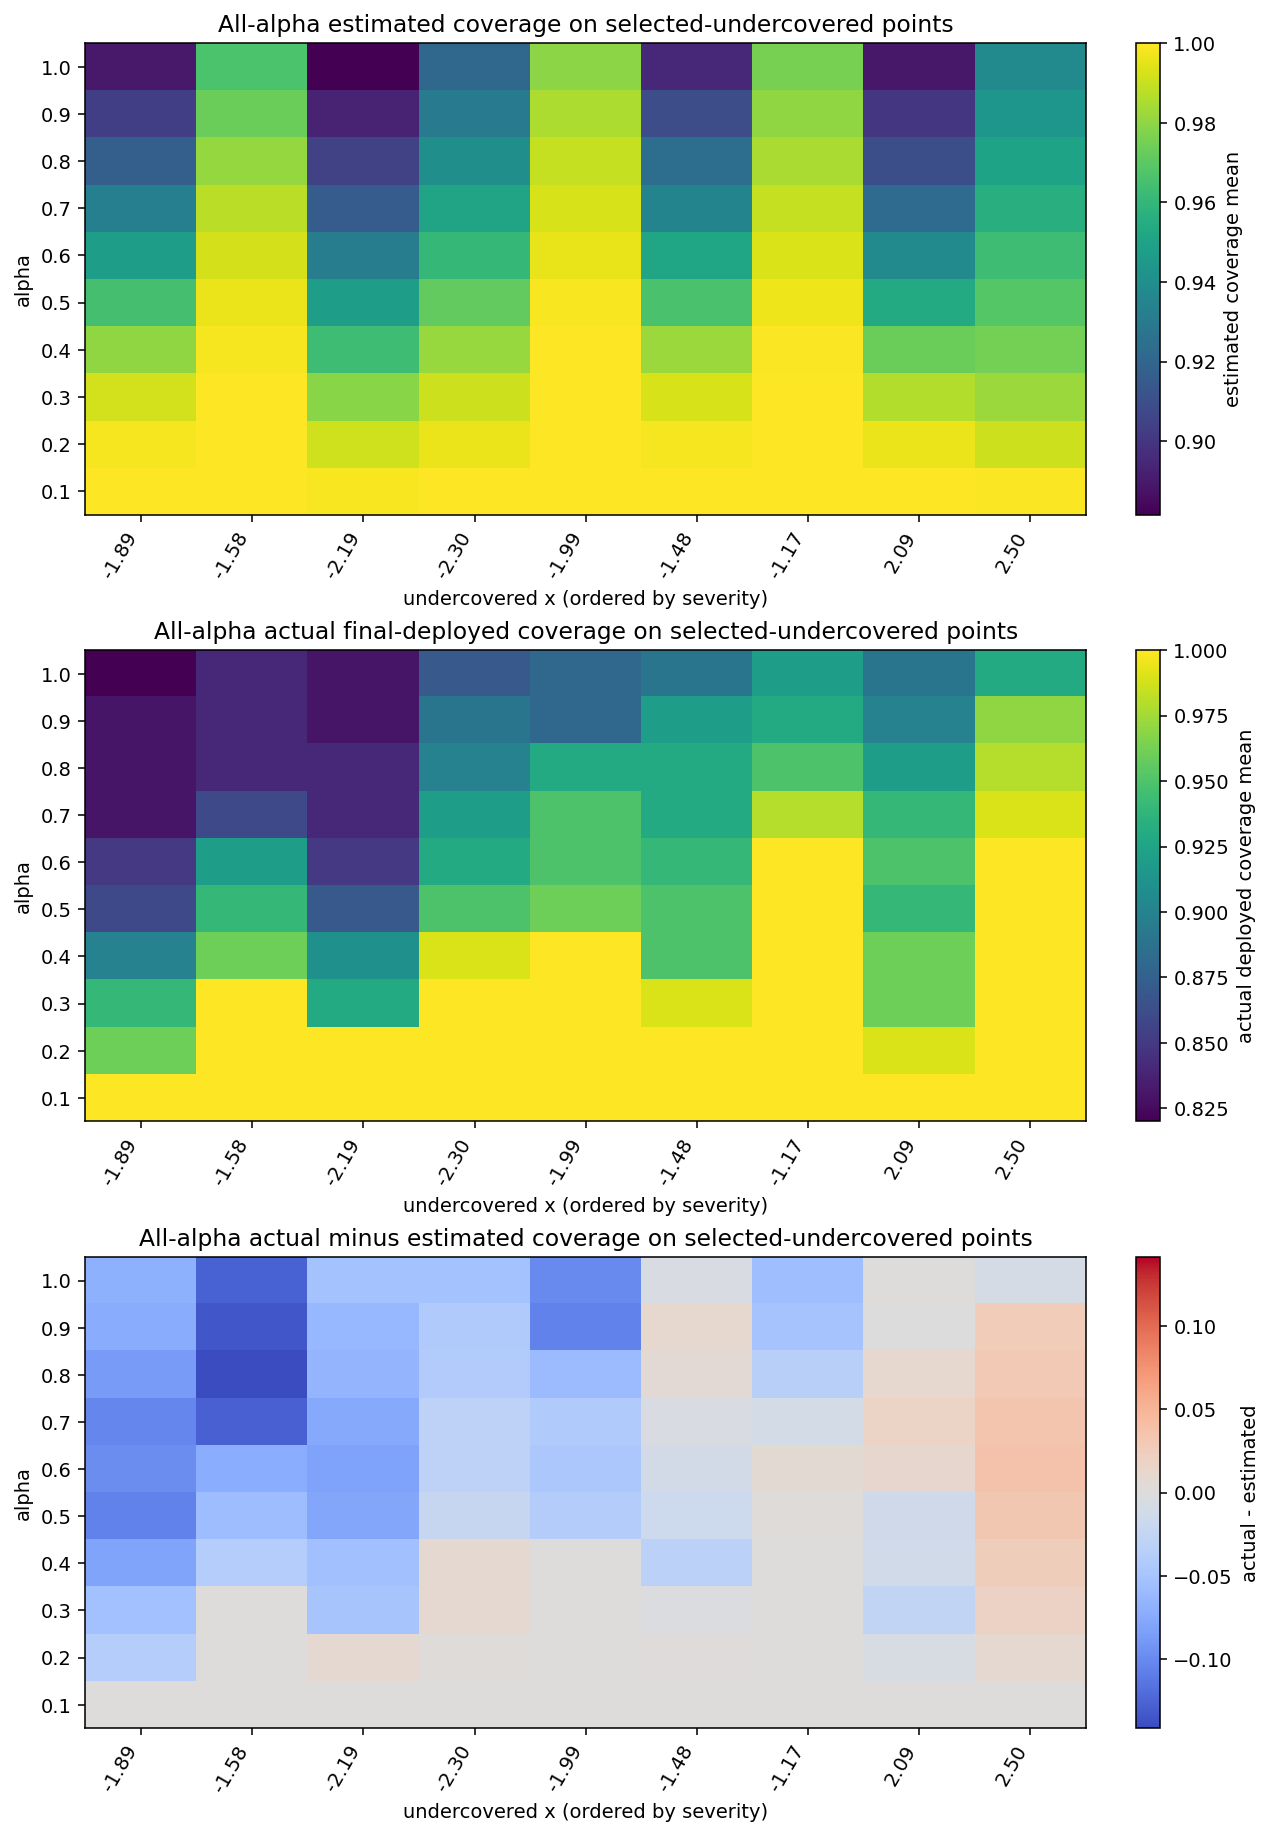

In [8]:
if U > 0:
    # reorder undercovered points by severity
    severity_order = np.argsort(pointwise_selected_deploy_cov[under_idx])
    under_idx_ord = under_idx[severity_order]
    under_x_ord = x_ref[under_idx_ord]

    est_under_ord = est_cov_all_mean[under_idx_ord, :]      # (U, A)
    act_under_ord = actual_cov_all_mean[under_idx_ord, :]   # (U, A)
    gap_under_ord = act_under_ord - est_under_ord

    fig, axes = plt.subplots(3, 1, figsize=(max(9, 0.55 * U), 13), constrained_layout=True)

    im0 = axes[0].imshow(est_under_ord.T, aspect="auto", origin="lower")
    axes[0].set_title("All-alpha estimated coverage on selected-undercovered points")
    axes[0].set_xlabel("undercovered x (ordered by severity)")
    axes[0].set_ylabel("alpha")
    axes[0].set_xticks(np.arange(U))
    axes[0].set_xticklabels([f"{x:.2f}" for x in under_x_ord], rotation=60, ha="right")
    axes[0].set_yticks(np.arange(A))
    axes[0].set_yticklabels([f"{a:.1f}" for a in alpha_vals_ref])
    fig.colorbar(im0, ax=axes[0], label="estimated coverage mean")

    im1 = axes[1].imshow(act_under_ord.T, aspect="auto", origin="lower")
    axes[1].set_title("All-alpha actual final-deployed coverage on selected-undercovered points")
    axes[1].set_xlabel("undercovered x (ordered by severity)")
    axes[1].set_ylabel("alpha")
    axes[1].set_xticks(np.arange(U))
    axes[1].set_xticklabels([f"{x:.2f}" for x in under_x_ord], rotation=60, ha="right")
    axes[1].set_yticks(np.arange(A))
    axes[1].set_yticklabels([f"{a:.1f}" for a in alpha_vals_ref])
    fig.colorbar(im1, ax=axes[1], label="actual deployed coverage mean")

    vmax = np.max(np.abs(gap_under_ord)) if gap_under_ord.size else 1.0
    im2 = axes[2].imshow(gap_under_ord.T, aspect="auto", origin="lower", vmin=-vmax, vmax=vmax, cmap="coolwarm")
    axes[2].set_title("All-alpha actual minus estimated coverage on selected-undercovered points")
    axes[2].set_xlabel("undercovered x (ordered by severity)")
    axes[2].set_ylabel("alpha")
    axes[2].set_xticks(np.arange(U))
    axes[2].set_xticklabels([f"{x:.2f}" for x in under_x_ord], rotation=60, ha="right")
    axes[2].set_yticks(np.arange(A))
    axes[2].set_yticklabels([f"{a:.1f}" for a in alpha_vals_ref])
    fig.colorbar(im2, ax=axes[2], label="actual - estimated")

    plt.savefig(OUTPUT_DIR / "03_undercovered_all_alpha_heatmaps.png", bbox_inches="tight")
    plt.show()

## Diagnostic 2: long-format all-alpha tables on the selected-undercovered points

These are useful for filtering and sorting outside the notebook.


In [9]:
if U > 0:
    long_rows = []
    for ui, j in enumerate(under_idx):
        x = float(x_ref[j])
        for ai, alpha in enumerate(alpha_vals_ref):
            long_rows.append({
                "x": x,
                "true_f": float(true_f_ref[j]),
                "alpha": float(alpha),
                "selected_deploy_coverage": float(pointwise_selected_deploy_cov[j]),
                "selected_estimated_coverage": float(pointwise_selected_est_cov[j]),
                "actual_deployed_coverage_mean": float(actual_cov_all_mean[j, ai]),
                "actual_deployed_coverage_sd": float(actual_cov_all_sd[j, ai]),
                "estimated_coverage_mean": float(est_cov_all_mean[j, ai]),
                "estimated_coverage_sd": float(est_cov_all_sd[j, ai]),
                "actual_minus_estimated": float(actual_cov_all_mean[j, ai] - est_cov_all_mean[j, ai]),
                "actual_abs_error_to_nominal": float(abs(actual_cov_all_mean[j, ai] - nominal)),
                "estimated_abs_error_to_nominal": float(abs(est_cov_all_mean[j, ai] - nominal)),
            })
    undercovered_all_alpha_long = pd.DataFrame(long_rows)
    undercovered_all_alpha_long.to_csv(
        OUTPUT_DIR / "04_undercovered_all_alpha_long.csv",
        index=False,
    )

undercovered_all_alpha_long.head() if U > 0 else None

,x,true_f,alpha,selected_deploy_coverage,selected_estimated_coverage,actual_deployed_coverage_mean,actual_deployed_coverage_sd,estimated_coverage_mean,estimated_coverage_sd,actual_minus_estimated,actual_abs_error_to_nominal,estimated_abs_error_to_nominal
0,-2.295918,-0.547295,0.1,0.88,0.978084,1.00,0.000000,1.0000,0.000000,0.0000,0.05,0.0500
1,-2.295918,-0.547295,0.2,0.88,0.978084,1.00,0.000000,0.9967,0.009646,0.0033,0.05,0.0467
2,-2.295918,-0.547295,0.3,0.88,0.978084,1.00,0.000000,0.9910,0.019822,0.0090,0.05,0.0410
3,-2.295918,-0.547295,0.4,0.88,0.978084,0.99,0.100000,0.9816,0.037247,0.0084,0.04,0.0316
4,-2.295918,-0.547295,0.5,0.88,0.978084,0.95,0.219043,0.9715,0.054037,-0.0215,0.00,0.0215


## Diagnostic 3: best-alpha-by-actual vs best-alpha-by-estimate

For each selected-undercovered point, compare:

- the alpha whose **estimated** mean coverage is closest to 0.95
- the alpha whose **actual final-deployed** mean coverage is closest to 0.95

This directly checks whether the deployed family already contains a usable alpha on that point.


In [10]:
if U > 0:
    compare_df = undercovered_all_alpha_compare[[
        "x",
        "true_f",
        "selected_deploy_coverage",
        "selected_estimated_coverage",
        "selected_deploy_minus_estimated",
        "best_alpha_by_estimated_mean",
        "best_alpha_estimated_coverage",
        "best_alpha_estimated_abs_error_to_nominal",
        "best_alpha_by_actual_deploy_mean",
        "best_alpha_actual_deploy_coverage",
        "best_alpha_actual_abs_error_to_nominal",
        "best_actual_minus_best_est",
    ]].copy()

    same_best_alpha = np.isclose(
        compare_df["best_alpha_by_estimated_mean"].to_numpy(dtype=float),
        compare_df["best_alpha_by_actual_deploy_mean"].to_numpy(dtype=float),
    )
    compare_df["best_alpha_match"] = same_best_alpha

    # simple project-aligned labels
    actual_tol = 0.02
    labels = []
    for _, row in compare_df.iterrows():
        if row["best_alpha_actual_abs_error_to_nominal"] <= actual_tol:
            if row["best_alpha_match"]:
                lbl = "actual_support_exists_same_alpha"
            else:
                lbl = "actual_support_exists_but_different_alpha"
        else:
            lbl = "no_actual_alpha_near_nominal"
        labels.append(lbl)
    compare_df["actual_support_label"] = labels

    compare_df.to_csv(OUTPUT_DIR / "05_undercovered_best_alpha_compare.csv", index=False)
    compare_df

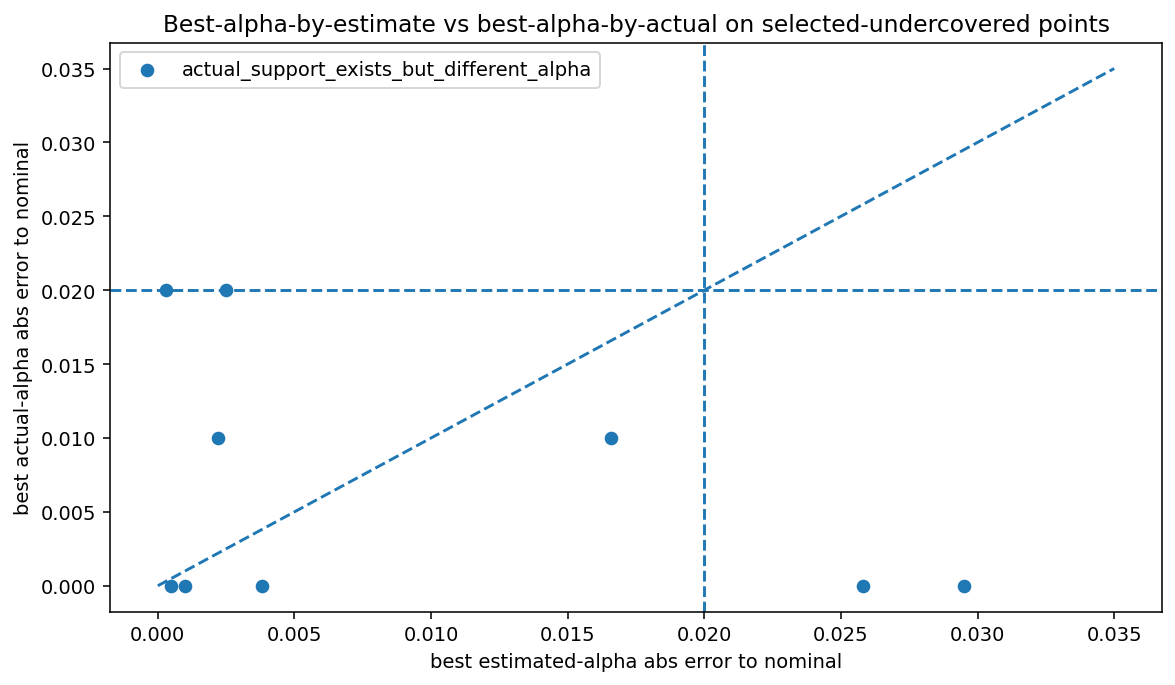

In [11]:
if U > 0:
    plt.figure(figsize=(8.5, 5.0))
    xvals = compare_df["best_alpha_estimated_abs_error_to_nominal"].to_numpy(dtype=float)
    yvals = compare_df["best_alpha_actual_abs_error_to_nominal"].to_numpy(dtype=float)

    for lbl in sorted(compare_df["actual_support_label"].unique()):
        mask = compare_df["actual_support_label"] == lbl
        plt.scatter(
            xvals[mask.to_numpy()],
            yvals[mask.to_numpy()],
            label=lbl,
        )

    lim_hi = max(xvals.max(initial=0.0), yvals.max(initial=0.0), 0.03) + 0.005
    plt.plot([0.0, lim_hi], [0.0, lim_hi], linestyle="--")
    plt.axhline(0.02, linestyle="--")
    plt.axvline(0.02, linestyle="--")
    plt.xlabel("best estimated-alpha abs error to nominal")
    plt.ylabel("best actual-alpha abs error to nominal")
    plt.title("Best-alpha-by-estimate vs best-alpha-by-actual on selected-undercovered points")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "05_best_alpha_est_vs_actual_scatter.png", bbox_inches="tight")
    plt.show()

## Diagnostic 4: all-alpha transfer gap summary on the selected-undercovered points

This summarizes whether the actual deployed all-alpha coverage is systematically
lower than the split-bootstrap estimated all-alpha coverage on the points that remain undercovered.


In [12]:
if U > 0:
    transfer_rows = []
    for j in under_idx:
        gap_vec = actual_cov_all_mean[j, :] - est_cov_all_mean[j, :]
        transfer_rows.append({
            "x": float(x_ref[j]),
            "selected_deploy_coverage": float(pointwise_selected_deploy_cov[j]),
            "selected_estimated_coverage": float(pointwise_selected_est_cov[j]),
            "mean_gap_over_all_alpha": float(np.mean(gap_vec)),
            "min_gap_over_all_alpha": float(np.min(gap_vec)),
            "max_gap_over_all_alpha": float(np.max(gap_vec)),
            "all_alpha_gap_negative": bool(np.all(gap_vec < 0.0)),
            "share_alpha_with_negative_gap": float(np.mean(gap_vec < 0.0)),
        })
    transfer_gap_df = pd.DataFrame(transfer_rows).sort_values(
        ["selected_deploy_coverage", "x"], ascending=[True, True]
    ).reset_index(drop=True)
    transfer_gap_df.to_csv(OUTPUT_DIR / "06_undercovered_transfer_gap_summary.csv", index=False)

transfer_gap_df if U > 0 else None

,x,selected_deploy_coverage,selected_estimated_coverage,mean_gap_over_all_alpha,min_gap_over_all_alpha,max_gap_over_all_alpha,all_alpha_gap_negative,share_alpha_with_negative_gap
0,-1.887755,0.84,0.984078,-0.07061,-0.1051,0.0000,False,0.9
1,-1.581633,0.84,0.972408,-0.06963,-0.1413,0.0000,False,0.7
2,-2.193878,0.87,0.984630,-0.05061,-0.0811,0.0084,False,0.8
3,-2.295918,0.88,0.978084,-0.01941,-0.0512,0.0090,False,0.6
4,-1.989796,0.89,0.970270,-0.03909,-0.1052,0.0004,False,0.6
5,-1.479592,0.91,0.981404,-0.00545,-0.0324,0.0104,False,0.6
6,-1.173469,0.92,0.972572,-0.01400,-0.0558,0.0067,False,0.4
7,2.091837,0.94,0.985154,-0.00198,-0.0264,0.0173,False,0.5
8,2.500000,0.94,0.977228,0.02017,-0.0083,0.0367,False,0.1


In [13]:
print("==== ALL-ALPHA FINAL DOUBLE CHECK SUMMARY ====")
for k, v in summary.items():
    print(f"{k}: {v}")

print()
print(f"Saved outputs to: {OUTPUT_DIR}")

print("Main tables:")
print(f"  {OUTPUT_DIR / '01_undercovered_selected_points_summary.csv'}")
print(f"  {OUTPUT_DIR / '02_undercovered_all_alpha_actual_vs_estimated.csv'}")
print(f"  {OUTPUT_DIR / '04_undercovered_all_alpha_long.csv'}")
print(f"  {OUTPUT_DIR / '05_undercovered_best_alpha_compare.csv'}")
print(f"  {OUTPUT_DIR / '06_undercovered_transfer_gap_summary.csv'}")

==== ALL-ALPHA FINAL DOUBLE CHECK SUMMARY ====
R: 100
J: 50
A: 10
rep_id_min: 0
rep_id_max: 99
nominal: 0.95
undercovered_selected_points: 9

Saved outputs to: C:\Users\yangy\26 spring\with reference\familyfix\results\all_alpha_final_double_check
Main tables:
  C:\Users\yangy\26 spring\with reference\familyfix\results\all_alpha_final_double_check\01_undercovered_selected_points_summary.csv
  C:\Users\yangy\26 spring\with reference\familyfix\results\all_alpha_final_double_check\02_undercovered_all_alpha_actual_vs_estimated.csv
  C:\Users\yangy\26 spring\with reference\familyfix\results\all_alpha_final_double_check\04_undercovered_all_alpha_long.csv
  C:\Users\yangy\26 spring\with reference\familyfix\results\all_alpha_final_double_check\05_undercovered_best_alpha_compare.csv
  C:\Users\yangy\26 spring\with reference\familyfix\results\all_alpha_final_double_check\06_undercovered_transfer_gap_summary.csv
